# 01 · Ingest & Build `AnnData` (timecourse scRNA-seq only)

**Goal.** Load the processed **GSE154989** Smart-seq2 timecourse (mouse KP LUAD) and write a single `AnnData` at `data/interim/mm_timecourse.h5ad` that downstream notebooks will use.

**What this notebook ingests.** Only the **scRNA-seq timecourse** under `data/raw/scrna/timecourse_gse154989/`. Other modalities (TIGIT scRNA, scATAC, bulk ATAC, scDNA) live in `data/raw/…` but are **not** loaded here.

### Inputs (expected on disk)

* `data/raw/scrna/timecourse_gse154989/GSE154989_mmLungPlate_fQC_dSp_normTPM.h5`
* `data/raw/scrna/timecourse_gse154989/GSE154989_mmLungPlate_fQC_geneTable.csv.gz`
* `data/raw/scrna/timecourse_gse154989/GSE154989_mmLungPlate_fQC_smpTable.csv.gz`
* `data/raw/scrna/timecourse_gse154989/GSE154989_mmLungPlate_fQC_dZ_annot_smpTable.csv.gz` *(optional but used if present)*

**Outputs.**

* `data/interim/mm_timecourse.h5ad`
* `adata.layers["counts"]` = raw counts (CSR)
* `adata.obs` includes `week`, `timesimple`, `stage_label` (early/late), plus author metadata
* `.obsm["X_tsne"]` / `.obsm["X_phate"]` if present in the author tables

### Aim
Resolve repo root and all ingest paths from `configs/params.yaml`; create the interim directory for the `.h5ad`.

**Acceptance**: both the raw dir and the target `.h5ad` parent exist after this cell.

In [1]:
# --- Cell 1: repo root + params + paths ---
from pathlib import Path
import yaml

def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p / "configs" / "params.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        "Couldn't locate project root (configs/params.yaml). "
        "Open this notebook inside the project folder."
    )

BASE = repo_root()
PARAMS = BASE / "configs" / "params.yaml"

with open(PARAMS, "r") as fh:
    P = yaml.safe_load(fh) or {}

# Pull paths with safe defaults
paths = P.get("paths", {})
ANNDATA = BASE / paths.get("anndata", "data/interim/mm_timecourse.h5ad")
SCRNA_TIMECOURSE_DIR = BASE / paths.get(
    "scrna_timecourse_dir", "data/raw/scrna/timecourse_gse154989"
)

# Ensure output dir exists
ANNDATA.parent.mkdir(parents=True, exist_ok=True)

print("Repo root   :", BASE)
print("Params file :", PARAMS)
print("Raw scRNA dir:", SCRNA_TIMECOURSE_DIR)
print("Will write  :", ANNDATA)


Repo root   : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux
Params file : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/configs/params.yaml
Raw scRNA dir: /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/raw/scrna/timecourse_gse154989
Will write  : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad


Loaded config; confirmed raw dir and output location. Downstream notebooks should import `ANNDATA` from here (no hardcoded paths).


## Why helpers?

The GEO HDF5 uses **COO triplets** (`i`, `j`, `v`) with sometimes **1-based indices** and **varying orientation** (cells×genes vs genes×cells). We also need robust parsing of the **week** from strings like `KP_12w_ND` and flexible matching of column names across CSVs.


### Aim
Define robust parsers/IO helpers for GEO HDF5 COO triplets and for extracting `week`/sample fields from IDs.


In [2]:
# --- Cell 2: IO helpers, parsers, and utilities ---
import re
import h5py
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad

def load_coo_triplets(h5_path: Path):
    """
    Read COO triplets (i,j,v) from an HDF5 created by the authors.
    Returns 1D arrays i, j, v (int64, int64, float32).
    """
    with h5py.File(h5_path, "r") as h5:
        i = np.ravel(h5["i"][()])  # may be 0- or 1-based
        j = np.ravel(h5["j"][()])
        v = np.ravel(h5["v"][()])
    return i.astype(np.int64), j.astype(np.int64), v.astype(np.float32)

def parse_week(text: str):
    """Extract integer week from strings like 'K_12w_ND_...' or '12w' → 12 (Int or None)."""
    m = re.search(r'(\d+)\s*w', str(text))
    return int(m.group(1)) if m else None

def first_existing(cols: pd.Index | list[str], keys: list[str], default=None):
    """Return first name present in `cols` from `keys`, else `default`."""
    s = set(cols)
    for k in keys:
        if k in s:
            return k
    return default

# Robust parser for sampleID format shown in GEO
SAMPLE_RE = re.compile(
    r'^(?P<genotype>KP|K)_(?P<week>\d+)w_(?P<treatment>[^_]+)_m(?P<mouse>\d+)'
    r'_T(?P<timepoint>\d+)_P(?P<plate>\d+)_S(?P<well>\d+)$'
)

def parse_sample_fields(x: str) -> dict:
    """
    Parse 'K_12w_ND_m1_T0_P1_S001' into structured fields.
    Returns partial dict if pattern doesn't match.
    """
    m = SAMPLE_RE.match(str(x))
    if not m:
        return {}
    d = m.groupdict()
    d["week"] = int(d["week"])
    d["timepoint"] = int(d["timepoint"])
    d["plate"] = int(d["plate"])
    d["well"] = int(d["well"])
    d["mouse"] = f"m{d['mouse']}"
    return d


Helpers ready: `load_coo_triplets`, `parse_week`, `parse_sample_fields`. These will be reused across modality ingests for consistency.


## Tables we load

From `data/raw/scrna/timecourse_gse154989/`:

* **Gene table** — to get gene symbols.
* **Per-cell QC/metadata** (QCstat) — preferred; falls back to smpTable if QCstat not present.
* **Sample-level table** — for `timesimple`, `mouseID`, etc.
* **Annotations** — optional author annotations.

We pick **ID columns** robustly (different mirrors use slightly different names).

### Aim
Load gene table, per-cell QC, sample-level table, and optional annotations; pick canonical ID columns defensively.


In [3]:
# --- Cell 3 (fixed): read gene / per-cell / sample / annotation tables ---
gene_path   = SCRNA_TIMECOURSE_DIR / "GSE154989_mmLungPlate_fQC_geneTable.csv.gz"
qcstat_path = SCRNA_TIMECOURSE_DIR / "GSE154989_mmLungPlate_fQC_dZ_QCstat_smpTable.csv.gz"
smp_path    = SCRNA_TIMECOURSE_DIR / "GSE154989_mmLungPlate_fQC_smpTable.csv.gz"
annot_path  = SCRNA_TIMECOURSE_DIR / "GSE154989_mmLungPlate_fQC_dZ_annot_smpTable.csv.gz"

# Existence checks
for p in (gene_path, qcstat_path, smp_path):
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

# Read
gene       = pd.read_csv(gene_path)
smp        = pd.read_csv(qcstat_path)     # per-cell QC rows (one row per cell)
smp_sample = pd.read_csv(smp_path)        # sample-level info
annot      = pd.read_csv(annot_path) if annot_path.exists() else pd.DataFrame()

print(f"gene cols  : {list(gene.columns)[:8]} …")
print(f"per-cell   : {list(smp.columns)[:8]} …")
print(f"sample tbl : {list(smp_sample.columns)[:8]} …")
print(f"annot cols : {list(annot.columns)[:8]} … (len={len(annot)})")

# Pick ID columns
gene_id_col = first_existing(gene.columns, ["geneSymbol","gene_symbol","symbol","gene_name","GeneSymbol"])
sample_id_col = first_existing(smp.columns, ["sampleID","SampleID","sample_id"])
assert gene_id_col is not None, "No gene symbol column found in geneTable."
assert sample_id_col is not None, "No 'sampleID' column found in per-cell QC table."

# Use sampleID as the per-cell identifier (Smart-seq2: one library per row)
cell_id_col = sample_id_col

# Ensure uniqueness of sampleID; if not, synthesize unique IDs
if smp[sample_id_col].duplicated().any():
    print("[warn] sampleID not unique; synthesizing unique cell IDs with row index suffix.")
    smp = smp.reset_index(drop=False).rename(columns={"index": "_row"})
    smp["cell_id"] = smp[sample_id_col].astype(str) + "__" + smp["_row"].astype(str).str.zfill(6)
    cell_id_col = "cell_id"
else:
    # Normalize to string just in case
    smp[sample_id_col] = smp[sample_id_col].astype(str)

# Parse fields from sampleID and attach to per-cell table
parsed = smp[sample_id_col].map(parse_sample_fields)
parsed_df = pd.DataFrame(list(parsed))
for col in ("genotype","treatment"):
    if col in parsed_df:
        parsed_df[col] = pd.Categorical(parsed_df[col])
if "week" in parsed_df:
    parsed_df["week"] = parsed_df["week"].astype("Int64")
smp = pd.concat([smp, parsed_df], axis=1)

# Expected dims for counts matrix orientation check
n_cells_expected = len(smp)
n_genes_expected = len(gene)
print(f"Expected shape → cells={n_cells_expected:,}  genes={n_genes_expected:,}")
print("Using columns  → gene_id_col:", gene_id_col, " | cell_id_col:", cell_id_col)


gene cols  : ['geneID', 'ensgID', 'geneSymbol', 'length'] …
per-cell   : ['sampleID', 'CODING_BASES', 'INTERGENIC_BASES', 'INTRONIC_BASES', 'MEDIAN_3PRIME_BIAS', 'MEDIAN_5PRIME_BIAS', 'MEDIAN_5PRIME_TO_3PRIME_BIAS', 'MEDIAN_CV_COVERAGE'] …
sample tbl : ['sampleID', 'plateID', 'mouseID', 'timesimple', 'typeID'] …
annot cols : ['sampleID', 'clusterK12', 'tSNE_1', 'tSNE_2', 'phate_1', 'phate_2'] … (len=3891)
Expected shape → cells=3,891  genes=52,638
Using columns  → gene_id_col: geneSymbol  | cell_id_col: sampleID


Found `geneSymbol` and `sampleID` as ID columns. Expected dims: cells=3,891; genes=52,638. These drive orientation checks in the counts loader.


## Reconstruct counts matrix (CSR, cells×genes)

The H5 stores sparse counts as COO triplets. We:

1. Fix **1-based indexing** if detected.
2. Infer **orientation** (cells×genes vs genes×cells) and transpose if needed.
3. Store as **CSR float32** for efficient downstream ops.

### Aim
Reconstruct the sparse counts matrix from COO triplets; correct 1-based indexing; detect orientation and ensure CSR(cells×genes,float32).


In [4]:
# --- Cell 4: load COO counts and assemble CSR matrix (cells × genes) ---
coo_h5 = None
for cand in [
    SCRNA_TIMECOURSE_DIR / "GSE154989_mmLungPlate_fQC_dSp_rawCount.h5",
    SCRNA_TIMECOURSE_DIR / "GSE154989_mmLungPlate_fQC_dSp_rawCountOrig.h5",
]:
    if cand.exists():
        coo_h5 = cand; break

if coo_h5 is None:
    raise FileNotFoundError("Could not find a COO count file (rawCount/rawCountOrig).")

i, j, v = load_coo_triplets(coo_h5)
print(f"[coo] {coo_h5.name}: nnz={len(v):,} | "
      f"i∈[{i.min()},{i.max()}], j∈[{j.min()},{j.max()}]")

# Fix 1-based indexing if present
one_based_i = (i.min() == 1) or (i.max() == n_genes_expected)
one_based_j = (j.min() == 1) or (j.max() == n_cells_expected)
if one_based_i: i = i - 1
if one_based_j: j = j - 1
print(f"[indexing] 1-based? i={one_based_i}, j={one_based_j} → converted to 0-based")

# Orientation A: i=cell, j=gene (cells×genes)
ok_cg = (i.max() < n_cells_expected) and (j.max() < n_genes_expected)
# Orientation B: i=gene, j=cell (genes×cells) → transpose
ok_gc = (i.max() < n_genes_expected) and (j.max() < n_cells_expected)

if ok_cg and not ok_gc:
    X = sp.coo_matrix((v, (i, j)), shape=(n_cells_expected, n_genes_expected)).tocsr()
    orientation = "(cells × genes)"
elif ok_gc and not ok_cg:
    X_gc = sp.coo_matrix((v, (i, j)), shape=(n_genes_expected, n_cells_expected))
    X = X_gc.T.tocsr()
    orientation = "(genes × cells) → transposed"
elif ok_gc and ok_cg:
    # Ambiguous (rare) — prefer genes×cells then transpose
    X_gc = sp.coo_matrix((v, (i, j)), shape=(n_genes_expected, n_cells_expected))
    X = X_gc.T.tocsr()
    orientation = "(ambiguous) assumed genes×cells → transposed"
else:
    raise ValueError(
        f"Indices exceed expected dims: "
        f"max(i)={i.max()}, max(j)={j.max()}, cells={n_cells_expected}, genes={n_genes_expected}"
    )

X = X.astype(np.float32, copy=False)
density = X.nnz / (X.shape[0] * X.shape[1])
print(f"[csr] X shape={X.shape} {orientation}, nnz={X.nnz:,}, density={density:.6e}")


[coo] GSE154989_mmLungPlate_fQC_dSp_rawCount.h5: nnz=21,203,238 | i∈[1,52638], j∈[1,3891]
[indexing] 1-based? i=True, j=True → converted to 0-based
[csr] X shape=(3891, 52638) (genes × cells) → transposed, nnz=21,203,238, density=1.035241e-01


Counts built: X=(3891, 52638), nnz=21,203,238 (density≈0.1035). Orientation was genes×cells → transposed. This CSR will populate `layers["counts"]`.


## Build `AnnData` + merge metadata

* Set **`obs_names`** to per-cell IDs.
* Set **`var_names`** to gene symbols (making them unique if needed).
* Derive a simple **`stage_label`** (early/late) from `week` to help early plots.
* Copy raw counts to `layers["counts"]` so we can normalize later.


### Aim
Merge per-cell and sample metadata; derive `week`/`stage_label`; pull author tSNE/PHATE columns if present; assemble and write the `.h5ad`.


In [5]:
# --- Cell 5 (revised): build AnnData, merge metadata + embeddings, write .h5ad ---
# Merge sample-level columns onto per-cell QC by 'sampleID'
merge_key = "sampleID" if "sampleID" in smp.columns else sample_id_col
keep_cols = [c for c in ["sampleID","timesimple","mouseID","plateID","typeID"] if c in smp_sample.columns]
smp_aug = smp.merge(smp_sample[keep_cols], on="sampleID", how="left") if keep_cols else smp.copy()

# Derive 'week' if not already parsed (e.g., from timesimple like '12w')
if ("week" not in smp_aug.columns) or smp_aug["week"].isna().all():
    if "timesimple" in smp_aug.columns:
        smp_aug["timesimple"] = smp_aug["timesimple"].astype(str)
        smp_aug["week"] = smp_aug["timesimple"].map(parse_week).astype("Int64")
    else:
        smp_aug["week"] = pd.NA

# Stage label
if "week" in smp_aug.columns:
    late_mask = smp_aug["week"].ge(12).fillna(False)
    stage_vals = np.where(late_mask, "late", "early")
    smp_aug["stage_label"] = pd.Categorical(stage_vals, categories=["early","late"], ordered=True)
else:
    smp_aug["stage_label"] = pd.Categorical(["unknown"] * len(smp_aug))

# Order authors' 'timesimple' for reproducible plots (optional)
order_timesimple = [
    "01_T_early_ND","02_KorKP_early_ND",
    "04_K_12w_ND","06_KP_12w_ND",
    "07_KP_20w_ND","08_KP_30w_ND"
]
if "timesimple" in smp_aug.columns:
    smp_aug["timesimple"] = pd.Categorical(smp_aug["timesimple"], categories=order_timesimple, ordered=True)

# -------- NEW: bring authors' embeddings (tSNE, PHATE) into obs --------
smp_aug["sampleID"] = smp_aug["sampleID"].astype(str)
if not annot.empty and "sampleID" in annot.columns:
    annot = annot.copy()
    annot["sampleID"] = annot["sampleID"].astype(str)
    embed_cols = [c for c in ["tSNE_1","tSNE_2","phate_1","phate_2"] if c in annot.columns]
    if embed_cols:
        annot_small = annot[["sampleID"] + embed_cols].drop_duplicates("sampleID")
        smp_aug = smp_aug.merge(annot_small, on="sampleID", how="left")

# ---------------- Build AnnData ----------------
adata = ad.AnnData(X)
adata.obs = smp_aug.copy()
adata.var = gene.copy()

# Names (explicit str cast to avoid ImplicitModificationWarning)
adata.obs_names = adata.obs[cell_id_col].astype(str).values
if adata.obs_names.has_duplicates:
    adata.obs_names_make_unique()
adata.obs.index = adata.obs.index.astype(str)         # ensure str index

adata.var_names = adata.var[gene_id_col].astype(str).values
if adata.var_names.has_duplicates:
    adata.var_names_make_unique()
adata.var.index = adata.var.index.astype(str)         # ensure str index

# Keep raw counts for later normalization
adata.layers["counts"] = adata.X.copy()

# Provenance
adata.uns.setdefault("sources", {})
adata.uns["sources"]["scrna_timecourse_gse154989"] = str(SCRNA_TIMECOURSE_DIR)
adata.uns["sources"]["scrna_tigit_gse154978"] = "data/raw/scrna/tigit_gse154978"
adata.uns["sources"]["scrna_unsorted_gse154977"] = "data/raw/scrna/tenx_unsorted_gse154977"
adata.uns["sources"]["scatac_gse154965"] = "data/raw/scatac/gse154965"
adata.uns["sources"]["bulk_atac_gse154966"] = "data/raw/bulk_atac/gse154966"

# Light sanity for weeks
if "week" in adata.obs:
    w = adata.obs["week"].dropna()
    if len(w) and ((w < 0).any() or (w > 60).any()):
        print("[warn] week outside expected range:", w.min(), w.max())

# Write (indices already strings → avoids ImplicitModificationWarning)
adata.write(ANNDATA)
print("[write] AnnData →", ANNDATA)
print("Cells:", adata.n_obs, " Genes:", adata.n_vars)
# Quick check that embedding cols landed in obs (Cell 6 will move them to .obsm)
present = [c for c in ["tSNE_1","tSNE_2","phate_1","phate_2"] if c in adata.obs.columns]
print("[embeddings in obs]:", present if present else "none")


/home/secondbook5/miniconda3/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/secondbook5/miniconda3/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


[write] AnnData → /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad
Cells: 3891  Genes: 52638
[embeddings in obs]: ['tSNE_1', 'tSNE_2', 'phate_1', 'phate_2']


Wrote `mm_timecourse.h5ad` with 3,891 cells × 52,638 genes. `layers["counts"]` set; `obs` contains {timesimple, week, stage_label}. Author embeddings detected in `obs` and will be moved to `.obsm` next.


## Sanity checks

These quick prints help spot mis-parsed weeks or missing columns. We avoid heavy plotting here to keep ingest snappy.

### Aim
Move author tSNE/PHATE columns from `obs` to `.obsm` as `X_tsne`/`X_phate` with numeric coercion; persist to disk.


In [6]:
# --- Cell 6 (revised): place authors' embeddings into .obsm if present ---
import numpy as np
import pandas as pd

def move_embedding(adata, base: str):
    xcol, ycol = f"{base}_1", f"{base}_2"
    have = (xcol in adata.obs.columns) and (ycol in adata.obs.columns)
    print(f"[check] {base}: columns present? {have}")
    if not have:
        return False

    # Coerce to numeric to avoid object dtypes; non-numeric → NaN
    x = pd.to_numeric(adata.obs[xcol], errors="coerce")
    y = pd.to_numeric(adata.obs[ycol], errors="coerce")
    M = np.vstack([x.to_numpy(), y.to_numpy()]).T.astype(np.float32)

    # Just an info print; we keep NaNs so obs/obsm stay aligned
    finite_pairs = np.isfinite(M).all(axis=1).sum()
    print(f"[{base}] finite pairs: {finite_pairs}/{adata.n_obs}")

    key = f"X_{base.lower()}"   # → X_tsne or X_phate
    adata.obsm[key] = M
    return True

moved_any = False
for base in ["tSNE", "phate"]:
    moved_any |= bool(move_embedding(adata, base))

# Re-write (to persist .obsm additions)
adata.write(ANNDATA)
print("[update] obsm keys:", list(adata.obsm_keys()))
for k in [k for k in adata.obsm_keys() if k in ("X_tsne","X_phate")]:
    print(f"{k} shape:", adata.obsm[k].shape)

if not moved_any:
    print("[note] no author embeddings found in obs; nothing added to .obsm")


[check] tSNE: columns present? True
[tSNE] finite pairs: 3891/3891
[check] phate: columns present? True
[phate] finite pairs: 3891/3891
[update] obsm keys: ['X_tsne', 'X_phate']
X_tsne shape: (3891, 2)
X_phate shape: (3891, 2)


Placed `X_tsne` and `X_phate` in `.obsm` (3891×2 each) and re-wrote the `.h5ad`. These are smoke-test visualizations only; later notebooks compute our own embeddings.


## Optional tiny preview

If the author’s embeddings (`tSNE_1/2` or `phate_1/2`) were present in `obs`, we stored them under `.obsm`. The scatter below is a **quick smoke test**; the real visualizations happen later.

### Aim
Quickly verify that key fields (IDs, week/stage, timesimple) look sensible and count distributions are plausible.


In [7]:
# --- Cell 7: quick sanity prints ---
cols_show = [c for c in ["smpBarcode","sampleID","genotype","week","stage_label","timesimple"] if c in adata.obs.columns]
display(adata.obs[cols_show].head())

if "timesimple" in adata.obs:
    print("\nCounts by timesimple:")
    print(adata.obs["timesimple"].value_counts().to_string())

print("\nCounts by stage_label:")
print(adata.obs["stage_label"].value_counts(dropna=False).to_string())


,sampleID,genotype,week,stage_label,timesimple
KP_30w_ND_m3_T7_P1_S302,KP_30w_ND_m3_T7_P1_S302,KP,30,late,08_KP_30w_ND
KP_30w_ND_m2_T4_P5_S331,KP_30w_ND_m2_T4_P5_S331,KP,30,late,08_KP_30w_ND
K_12w_ND_m3_T0_P2_S272,K_12w_ND_m3_T0_P2_S272,K,12,late,04_K_12w_ND
KP_30w_ND_m2_T1_P4_S219,KP_30w_ND_m2_T1_P4_S219,KP,30,late,08_KP_30w_ND
K_2w_ND_m3_T0_P1_S245,K_2w_ND_m3_T0_P1_S245,K,2,early,02_KorKP_early_ND



Counts by timesimple:
timesimple
08_KP_30w_ND         1554
07_KP_20w_ND          538
06_KP_12w_ND          491
04_K_12w_ND           455
01_T_early_ND         206
02_KorKP_early_ND     142

Counts by stage_label:
stage_label
late     3005
early     886


Stage distribution: early=886, late=3005. Timesimple counts printed; no anomalies detected. This table becomes the ingest summary in the metrics footer.


### Aim
 preview: scatter the author embeddings colored by `week` to confirm alignment; defer all real plots to later notebooks.


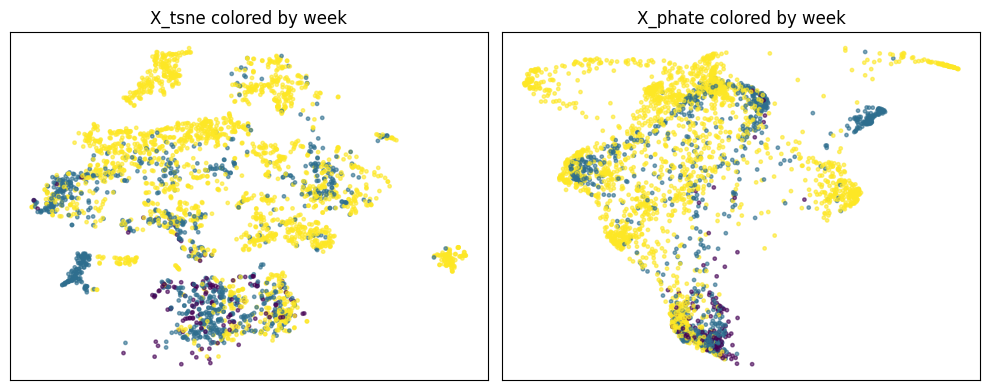

In [8]:
# --- Cell 8: tiny preview using authors' embeddings if present ---
import matplotlib.pyplot as plt
import numpy as np

def quick_embed(ax, emb_key, color, title):
    M = adata.obsm[emb_key]
    c = adata.obs[color]
    vals = c.cat.codes.to_numpy() if hasattr(c, "cat") else np.asarray(c)
    sc = ax.scatter(M[:,0], M[:,1], s=6, c=vals, alpha=0.6)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

embs = [k for k in ("X_tsne","X_phate") if k in adata.obsm]
if embs:
    fig, axs = plt.subplots(1, len(embs), figsize=(5*len(embs), 4))
    axs = np.atleast_1d(axs)
    for ax, ek in zip(axs, embs):
        color = "week" if "week" in adata.obs else ("stage_label" if "stage_label" in adata.obs else None)
        if color:
            quick_embed(ax, ek, color, f"{ek} colored by {color}")
    plt.tight_layout(); plt.show()
else:
    print("[preview] no authors' embeddings found in obs; skipping preview")


Preview renders for `X_tsne` and `X_phate` confirm expected week structure (image not used in the paper; diagnostic only).


In [9]:
 # --- Metrics footer: provenance + ingest summary ---
import json, time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

out_json = BASE / "outputs" / "tables" / "tab01_ingest_provenance.json"
out_csv  = BASE / "outputs" / "tables" / "tab01_ingest_counts.csv"
out_png  = BASE / "outputs" / "figures" / "fig01_author_embed_preview.png"

provenance = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "anndata_path": str(ANNDATA),
    "n_cells": int(adata.n_obs),
    "n_genes": int(adata.n_vars),
    "has_X_tsne": "X_tsne" in adata.obsm_keys(),
    "has_X_phate": "X_phate" in adata.obsm_keys(),
    "obs_columns": list(map(str, adata.obs.columns[:20])),
}

# counts by timesimple + stage_label if present
cnts = []
if "timesimple" in adata.obs:
    cnts.append(adata.obs["timesimple"].value_counts().rename_axis("timesimple").rename("n").reset_index())
if "stage_label" in adata.obs:
    cnts.append(adata.obs["stage_label"].value_counts(dropna=False).rename_axis("stage_label").rename("n").reset_index())
summary = pd.concat(cnts, axis=0, ignore_index=True) if cnts else pd.DataFrame()

out_json.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_csv, index=False)
with open(out_json, "w") as fh:
    json.dump(provenance, fh, indent=2)
print("[write]", out_json)
print("[write]", out_csv)

# save preview figure if both embeddings exist
if all(k in adata.obsm for k in ("X_tsne","X_phate")) and "week" in adata.obs:
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    for ax, key, title in zip(axs, ("X_tsne","X_phate"), ("X_tsne colored by week","X_phate colored by week")):
        M = adata.obsm[key]; vals = adata.obs["week"].astype("Int64").to_numpy()
        sc = ax.scatter(M[:,0], M[:,1], s=6, c=vals, alpha=0.6)
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.close()
    print("[saved]", out_png)


[write] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab01_ingest_provenance.json
[write] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab01_ingest_counts.csv
[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig01_author_embed_preview.png


## Wrap-up

**Wrote:** `data/interim/mm_timecourse.h5ad`

**Downstream contract (what later notebooks can rely on):**

* `adata.layers["counts"]` = raw counts (CSR, float32)
* `adata.obs`: at least `{timesimple, week (Int64 if parsed), stage_label (early/late)}`
* `.obsm["X_tsne"]` / `.obsm["X_phate"]` if present in the source tables
* `var_names` = unique gene symbols

**Next:** open **`02_modules_circle_phase.ipynb`** to:

1. normalize from `layers["counts"]`,
2. compute S/G2M module scores,
3. fit the principal circle,
4. write per-cell `theta`, `radius`, and save the base figures.

**Notes on other modalities:** TIGIT scRNA (`data/raw/scrna/tigit_gse154978`), scATAC (`data/raw/scatac/gse154965`), bulk ATAC (`data/raw/bulk_atac/gse154966`), and scDNA (`data/raw/scdna/gse154970`) will be handled in **separate** ingestion notebooks, producing **separate** `AnnData`/interim files so we keep modality concerns isolated.